<a href="https://colab.research.google.com/github/tsal4/data2000_labs/blob/main/homework/070_image-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

# Image Classification: Fashion MNIST

The Fashion MNIST dataset is a large freely available database of fashion images that is commonly used for training and testing various machine learning systems. Fashion-MNIST was intended to serve as a replacement for the original MNIST database for benchmarking machine learning algorithms, as it shares the same image size, data format and the structure of training and testing splits.

The dataset contains 70,000 28x28 grayscale images of fashion products from 10 categories from a dataset of Zalando article images, with 7,000 images per category. The training set consists of 60,000 images and the test set consists of 10,000 images. The dataset is commonly included in standard machine learning libraries. (Source: [Wikipedia](https://en.wikipedia.org/wiki/Fashion_MNIST))

The classes are:

| Label | Description |
|-----|-----|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## Objective

The goal here is to simply build and fit the best convolutional neural network that you can to correctly classify these image instances. Describe your process and choices as you go, and include an evaluation of your model's performance.

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


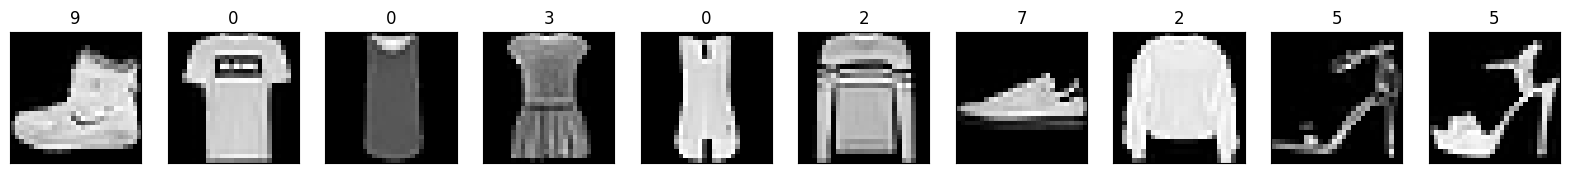

In [3]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i])
    plt.title(f'{y_train[i]}')
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [4]:
img_input = tf.keras.layers.Input(shape = (28,28,1))

**I decided not to do any augmenting of the images because there are already 60,000 images in the trainng set. I figured that was more than enough for an accurate model. If the model performs poorly, then I would go back and add the augmentation to improve model performance.**

In [5]:
conv1 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=4,
    activation="relu",
)(img_input)
conv1 = tf.keras.layers.AveragePooling2D(2)(conv1)

conv2 = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=4,
    activation="relu",
)(conv1)
conv2 = tf.keras.layers.AveragePooling2D(2)(conv2)

conv3 = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=4,
    activation="relu",
)(conv2)
conv3 = tf.keras.layers.AveragePooling2D(2)(conv3)

**I'm using three convolutional layers with increasing filters of 16, 32, and 64. This allows the model to capture more and more complex patterns in each layer.**

In [6]:
flattened = tf.keras.layers.Flatten()(conv2)
dropout = tf.keras.layers.Dropout(0.4)(flattened)

dense1 = tf.keras.layers.Dense(256, activation="relu")(dropout)
dense2 = tf.keras.layers.Dense(128, activation="relu")(dense1)

output = tf.keras.layers.Dense(10, activation="softmax")(dense2)

**I'm using a dropout layer of 40% to avoid overfitting. I'm using a higher percentage because of the amount of data in the dataset.**  
**The output layer has 10 parameters because of the 10 categories of clothing from which the model will predict.**  
**Finally, the softmax activation function maintains that all prediction probabilities add up to 1. This way, each prediction probability will act a percent chance that the real label is equal to the prediction.**

In [7]:
model = tf.keras.Model(img_input, output)

In [8]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

**I am using SparseCategoricalCrossentropy because we are classifying images based on categories.**

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 25, 25, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 32)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,010 (679.73 KB)

 Trainable params: 174,010 (679.73 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=30,
    shuffle=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.7311 - sparse_categorical_accuracy: 0.7276 - val_loss: 0.5595 - val_sparse_categorical_accuracy: 0.7856
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5077 - sparse_categorical_accuracy: 0.8082 - val_loss: 0.4618 - val_sparse_categorical_accuracy: 0.8222
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4451 - sparse_categorical_accuracy: 0.8329 - val_loss: 0.4075 - val_sparse_categorical_accuracy: 0.8491
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4046 - sparse_categorical_accuracy: 0.8485 - val_loss: 0.3734 - val_sparse_categorical_accuracy: 0.8573
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3742 - sparse_categorical_accuracy: 0.8608 - val_loss: 0.3651 - val_sparse_categorical_accuracy: 0.8616
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3565 - sparse_categorical_accuracy: 0.8668 - val_loss: 0.3390 - val_sparse_categorical_accuracy: 0.8777
Ep

<Figure size 640x480 with 0 Axes>

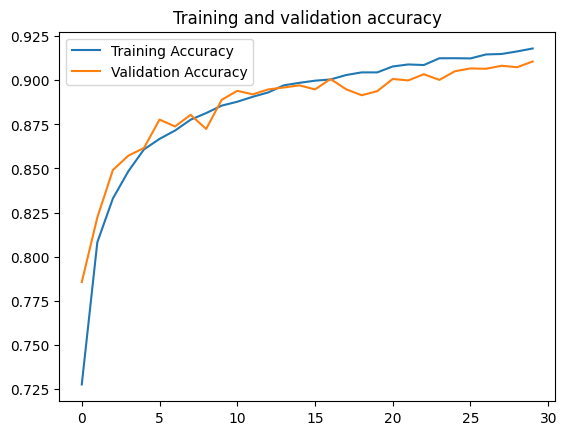

<Figure size 640x480 with 0 Axes>

In [11]:
acc = history.history['sparse_categorical_accuracy']
val_acc = history.history['val_sparse_categorical_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and validation accuracy')

plt.figure()

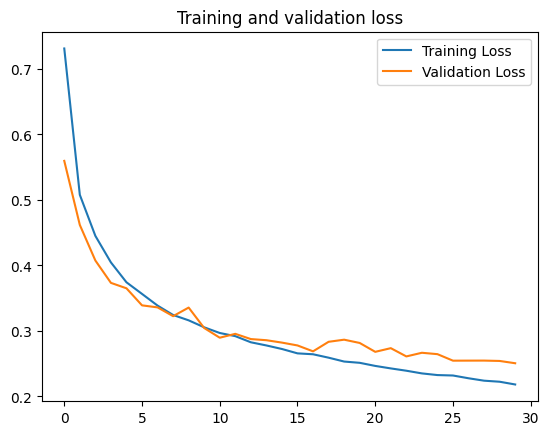

In [12]:
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and validation loss')
plt.show()

**I used the standard graphs we've been using in class to evaluate the model. This model was very accurate with and probably could be even more accurate with some image augmentation and more epochs (sinced it trained for the full 30 epochs). I started at 20 epochs and saw it went for the full 20, so I increased it to 30. I wonder if its the data being super optimal instead of my model being good.**